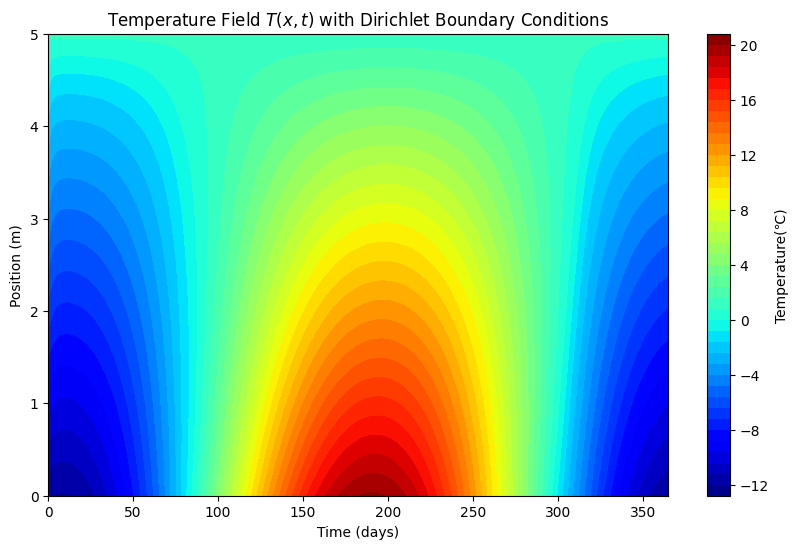

<Figure size 640x480 with 0 Axes>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
L = 3.34e5  # Latent heat of phase change (KJ/m^3)
C_i = 1.672  # Heat capacity of ice (KJ/(m^3·K))
C_l = 4.18  # Heat capacity of water (KJ/(m^3·K))
lambda_i = 2.210  # Thermal conductivity of ice (W/(m·K))
lambda_l = 0.465  # Thermal conductivity of water (W/(m·K))
eta = 0.4  # Porosity of the soil
b = 1.5  # Coefficient for unfrozen water content
T_nabla = -1.0  # Freezing temperature of the soil (°C)

# Discretization parameters
Nx = 50  # Number of spatial points
Nt = 100000  # Number of time steps
Lx = 5.0  # Length of the domain (m) (from 0 m to 5.0 m)
T_total = 365.0  # Total time (days)
dx = Lx / (Nx - 1)  # Spatial step size
dt = T_total / Nt  # Time step size

# Define functions
def pore_water_content(T, T_nabla, b):
    """Calculate pore water content."""
    return np.where(T >= T_nabla, 1, np.abs(T_nabla)**b * np.abs(T)**(-b))

def unfrozen_water_content(T, T_nabla, b, eta):
    """Calculate unfrozen water content."""
    phi = pore_water_content(T, T_nabla, b)
    return eta * phi

def effective_concentration(C_f, C_l, C_i, eta, phi):
    """Calculate effective heat capacity."""
    C_t_value = C_f + eta * (C_l - C_i)
    return phi * C_t_value + (1 - phi) * C_f

def effective_lambda(lambda_f, lambda_l, lambda_i, eta, phi):
    """Calculate effective thermal conductivity."""
    lambda_t_value = lambda_f * (lambda_l / lambda_i) ** eta
    return lambda_t_value ** phi * lambda_f ** (1 - phi)

# Boundary condition function
def temperature(t):
    """Boundary temperature function at x=0."""
    return 4.03 + 16.11 * np.sin((2 * np.pi * t / 365) - 1.709)  # Temperature in °C

# Linear interpolation function
def linear_interpolation(z, z1, z2, T1, T2):
    """
    Linear interpolation to calculate temperature at depth z.
    """
    if z1 == z2:
        raise ValueError("z1 and z2 cannot be the same.")
    return T1 + (T2 - T1) / (z2 - z1) * (z - z1)

# Initialize temperature profile using linear interpolation
def initialize_temperature_profile(depths, z1, z2, T1, T2):
    """
    Initialize temperature profile using linear interpolation.
    """
    temperatures = np.zeros_like(depths)
    for i, z in enumerate(depths):
        temperatures[i] = linear_interpolation(z, z1, z2, T1, T2)
    return temperatures

# Define spatial grid
x = np.linspace(0, Lx, Nx)  # Spatial grid from 0 m to 5.0 m

# Define boundary conditions for interpolation
z1, T1 = 0.0, temperature(0)  # Upper boundary condition at x=0 m
z2, T2 = Lx, 1.0  # Lower boundary condition at x=5.0 m (1 °C)

# Initialize temperature profile
T = initialize_temperature_profile(x, z1, z2, T1, T2)

# Initialize the temperature field as a 2D array
T_field = np.zeros((Nx, Nt))  # Temperature field: T(x, t)
T_field[:, 0] = T  # Set initial condition

# Time-stepping loop
for n in range(Nt):
    t_n = n * dt
    
    # Apply Dirichlet boundary conditions
    T[0] = temperature(t_n)  # Upper boundary condition at x=0 m
    T[-1] = 1.0  # Lower boundary condition at x=5.0 m (1 °C)
    
    # Compute effective properties
    phi = pore_water_content(T, T_nabla, b)
    theta = unfrozen_water_content(T, T_nabla, b, eta)
    C_eff = effective_concentration(C_i, C_l, C_i, eta, phi)
    lambda_eff = effective_lambda(lambda_i, lambda_l, lambda_i, eta, phi)
    
    # Debugging: Print intermediate values
    if np.any(np.isnan(C_eff)) or np.any(np.isnan(lambda_eff)):
        print(f"Warning: NaN detected at t = {t_n}")
        print("C_eff:", C_eff)
        print("lambda_eff:", lambda_eff)
        break
    
    # Compute the right-hand side of the discretized equation
    rhs = np.zeros(Nx)
    for i in range(1, Nx-1):
        lambda_plus = 0.5 * (lambda_eff[i] + lambda_eff[i+1])
        lambda_minus = 0.5 * (lambda_eff[i] + lambda_eff[i-1])
        rhs[i] = (lambda_plus * (T[i+1] - T[i]) - lambda_minus * (T[i] - T[i-1])) / dx**2
    
    # Update temperature
    T[1:-1] += dt * (rhs[1:-1] - L * (theta[1:-1] - theta[1:-1]) / dt) / C_eff[1:-1]
    
    # Store the temperature field at the current time step
    T_field[:, n] = T

# Plot the temperature field as a 2D image
plt.figure(figsize=(10, 6))
# 解析解
plt.contourf(np.linspace(0, T_total, Nt), x, T_field, levels=50, cmap='jet')
plt.colorbar(label='Temperature(℃)')
plt.xlabel('Time (days)')
plt.ylabel('Depth (m)')
plt.title('FDM Solution')
plt.xlabel('Time (days)')
plt.ylabel('Position (m)')
plt.title('Temperature Field $T(x, t)$ with Dirichlet Boundary Conditions')
plt.show()

# Save the plot as an image
plt.savefig('temperature_field_dirichlet.png', dpi=300, bbox_inches='tight')

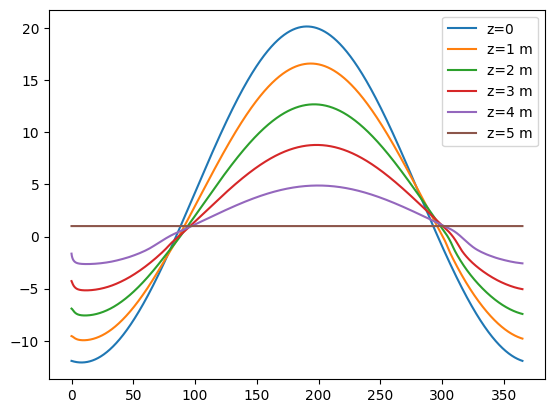

In [2]:
plt.plot(np.linspace(0, T_total, Nt),T_field[0,:],label = 'z=0')
plt.plot(np.linspace(0, T_total, Nt),T_field[9,:],label = 'z=1 m')
plt.plot(np.linspace(0, T_total, Nt),T_field[19,:],label = 'z=2 m')
plt.plot(np.linspace(0, T_total, Nt),T_field[29,:],label = 'z=3 m')
plt.plot(np.linspace(0, T_total, Nt),T_field[39,:],label = 'z=4 m')
plt.plot(np.linspace(0, T_total, Nt),T_field[49,:],label = 'z=5 m')
plt.legend()

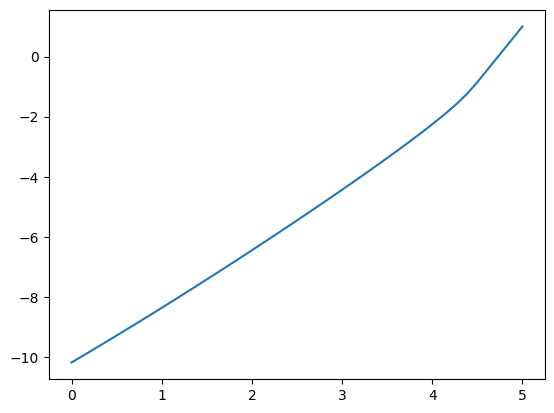

In [3]:
plt.plot(x,T_field[:,10000])

## PINNs来反演

Epoch     0, Loss: 6.020e+02 | PDE: 4.121e-03 | BC0: 1.402e+02 | BCL: 1.260e+00 | IC: 4.852e+01
Epoch   500, Loss: 3.970e+08 | PDE: 3.970e+03 | BC0: 1.865e+02 | BCL: 3.029e+01 | IC: 1.467e+01
Epoch  1000, Loss: 2.247e+08 | PDE: 2.247e+03 | BC0: 1.892e+02 | BCL: 3.368e+01 | IC: 1.460e+01
Epoch  1500, Loss: 1.666e+08 | PDE: 1.666e+03 | BC0: 1.890e+02 | BCL: 3.602e+01 | IC: 1.457e+01
Epoch  2000, Loss: 1.386e+08 | PDE: 1.386e+03 | BC0: 1.855e+02 | BCL: 3.731e+01 | IC: 1.456e+01
Epoch  2500, Loss: 1.253e+08 | PDE: 1.253e+03 | BC0: 1.848e+02 | BCL: 3.807e+01 | IC: 1.455e+01
Epoch  3000, Loss: 1.179e+08 | PDE: 1.179e+03 | BC0: 1.850e+02 | BCL: 3.853e+01 | IC: 1.455e+01
Epoch  3500, Loss: 1.135e+08 | PDE: 1.135e+03 | BC0: 1.851e+02 | BCL: 3.882e+01 | IC: 1.454e+01
Epoch  4000, Loss: 1.108e+08 | PDE: 1.108e+03 | BC0: 1.852e+02 | BCL: 3.899e+01 | IC: 1.454e+01
Epoch  4500, Loss: 1.091e+08 | PDE: 1.091e+03 | BC0: 1.852e+02 | BCL: 3.910e+01 | IC: 1.454e+01
Epoch  5000, Loss: 1.080e+08 | PDE: 1.08

/environment/miniconda3/lib/python3.11/site-packages/torch/functional.py:507: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3549.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


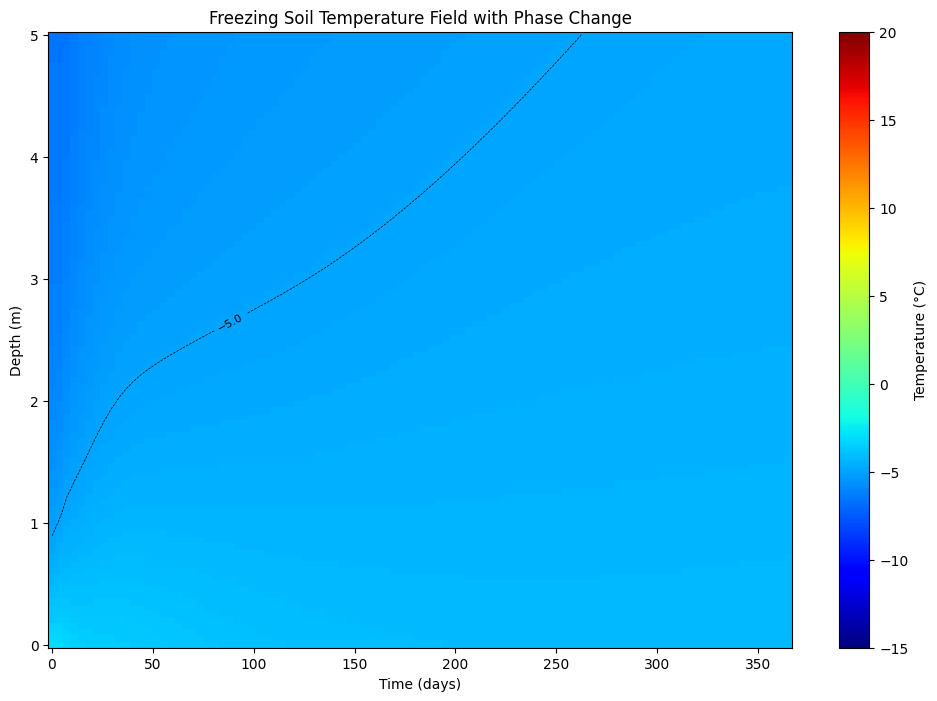

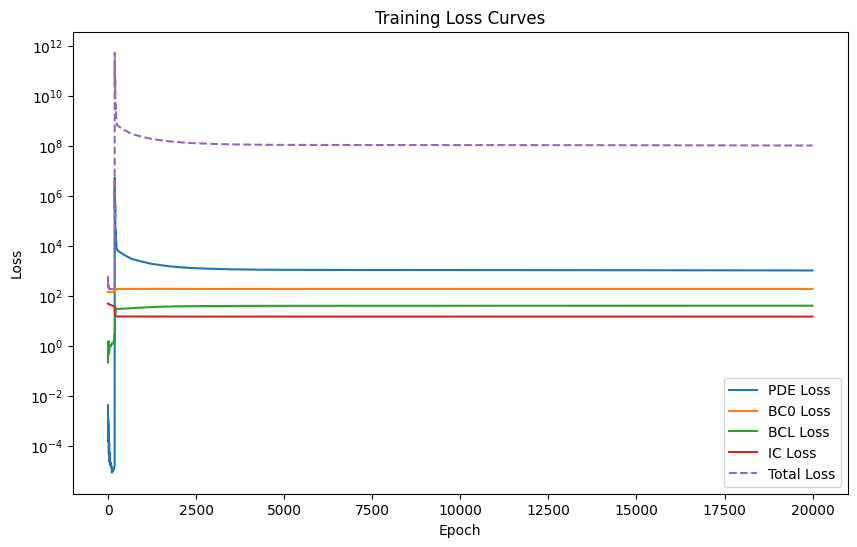

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import random

# 设定随机种子保证可重复性
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed(42)

# 神经网络定义
class PhaseChangePINN(nn.Module):
    def __init__(self, layers, activation='tanh'):
        super().__init__()
        self.net = nn.Sequential()
        for i in range(len(layers)-1):
            self.net.add_module(f'linear_{i}', nn.Linear(layers[i], layers[i+1]))
            if i < len(layers)-2:
                self.net.add_module(f'{activation}_{i}', nn.Tanh() if activation == 'tanh' else nn.SiLU())
        # 参数初始化
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)

# PINNs求解器类
class FreezingSoilPINN:
    def __init__(self, params, device='cuda'):
        # 物理参数
        self.device = device
        self.L = torch.tensor(params['L'], device=device)
        self.C_i = torch.tensor(params['C_i'], device=device)
        self.C_l = torch.tensor(params['C_l'], device=device)
        self.C_f = torch.tensor(params['C_f'], device=device)
        self.lambda_i = torch.tensor(params['lambda_i'], device=device)
        self.lambda_l = torch.tensor(params['lambda_l'], device=device)
        self.lambda_f = torch.tensor(params['lambda_f'], device=device)
        self.eta = torch.tensor(params['eta'], device=device)
        self.b = torch.tensor(params['b'], device=device)
        self.T_nabla = torch.tensor(params['T_nabla'], device=device)
        
        # 神经网络
        self.model = PhaseChangePINN([2, 64, 64, 64, 1]).to(device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=1e-3)
        self.scheduler = optim.lr_scheduler.ReduceLROnPlateau(self.optimizer, patience=500, factor=0.5)
        
        # 损失记录
        self.loss_history = []
        self.pde_loss = []
        self.bc0_loss = []
        self.bcL_loss = []
        self.ic_loss = []

    def _pore_water(self, T):
        """孔隙水含量计算"""
        return torch.where(T >= self.T_nabla,
                          torch.ones_like(T),
                          torch.abs(self.T_nabla)**self.b * torch.abs(T)**(-self.b))

    def _unfrozen_water(self, T):
        """未冻水含量计算"""
        return self.eta * self._pore_water(T)

    def _effective_heat_capacity(self, T):
        """有效热容计算"""
        phi = self._pore_water(T)
        return (1-self.eta)*self.C_f + self.eta*(phi*self.C_l + (1-phi)*self.C_i)

    def _effective_conductivity(self, T):
        """有效导热系数计算"""
        phi = self._pore_water(T)
        return (1-self.eta)*self.lambda_f + self.eta*(phi*self.lambda_l + (1-phi)*self.lambda_i)

    def _boundary_temp(self, t):
        """上边界温度函数 (x=0)"""
        return 4.03 + 16.11*torch.sin(2*np.pi*t/365 - 1.709)

    def _initial_temp(self, x):
        """初始温度场 (t=0) 线性插值"""
        z1, z2 = 0.0, 5.0
        T1 = self._boundary_temp(torch.tensor(0.0)).item()  # t=0时的上边界温度
        T2 = 1.0  # 下边界温度
        return T1 + (T2 - T1)/(z2 - z1) * x

    def compute_loss(self, x, t):
        # 前向传播
        T_pred = self.model(torch.cat([x, t], dim=1))
        
        # 计算梯度
        dT_dt = torch.autograd.grad(T_pred, t, grad_outputs=torch.ones_like(T_pred), 
                                   create_graph=True, retain_graph=True)[0]
        dT_dx = torch.autograd.grad(T_pred, x, grad_outputs=torch.ones_like(T_pred),
                                   create_graph=True, retain_graph=True)[0]
        d2T_dx2 = torch.autograd.grad(dT_dx, x, grad_outputs=torch.ones_like(dT_dx),
                                     create_graph=True, retain_graph=True)[0]
        
        # 物性参数计算
        C_eff = self._effective_heat_capacity(T_pred)
        lambda_eff = self._effective_conductivity(T_pred)
        theta = self._unfrozen_water(T_pred)
        dtheta_dt = torch.autograd.grad(theta, t, grad_outputs=torch.ones_like(theta),
                                       create_graph=True, retain_graph=True)[0]
        
        # PDE残差
        pde_res = C_eff*dT_dt - lambda_eff*d2T_dx2 - self.L*dtheta_dt
        pde_loss = torch.mean(pde_res**2)
        
        # 上边界条件 (x=0)
        bc0_mask = (x == 0).squeeze()
        bc0_pred = T_pred[bc0_mask]
        bc0_true = self._boundary_temp(t[bc0_mask])
        bc0_loss = torch.mean((bc0_pred - bc0_true)**2)
        
        # 下边界条件 (x=5)
        bcL_mask = (x == 5).squeeze()
        bcL_pred = T_pred[bcL_mask]
        bcL_true = torch.ones_like(bcL_pred)  # 固定温度1°C
        bcL_loss = torch.mean((bcL_pred - bcL_true)**2)
        
        # 初始条件 (t=0)
        ic_mask = (t == 0).squeeze()
        ic_pred = T_pred[ic_mask]
        ic_true = self._initial_temp(x[ic_mask]).unsqueeze(1)
        ic_loss = torch.mean((ic_pred - ic_true)**2)
        
        # 返回总损失和各分项损失
        return 1e5*pde_loss + bc0_loss + bcL_loss + ic_loss, pde_loss, bc0_loss, bcL_loss, ic_loss

    def train(self, x_domain, t_domain, epochs=20000, n_samples=10000):
        # 生成训练数据
        x = torch.rand(n_samples, 1, device=self.device)*(x_domain[1]-x_domain[0]) + x_domain[0]
        t = torch.rand(n_samples, 1, device=self.device)*(t_domain[1]-t_domain[0]) + t_domain[0]
        x.requires_grad_(True)
        t.requires_grad_(True)
        
        # 添加边界点强制采样
        bc0_points = torch.zeros(500, 1, device=self.device)
        bc0_times = torch.rand(500, 1, device=self.device)*t_domain[1]
        bcL_points = torch.ones(500, 1, device=self.device)*5.0
        bcL_times = torch.rand(500, 1, device=self.device)*t_domain[1]
        ic_points = torch.rand(500, 1, device=self.device)*5.0
        ic_times = torch.zeros(500, 1, device=self.device)
        
        x = torch.cat([x, bc0_points, bcL_points, ic_points])
        t = torch.cat([t, bc0_times, bcL_times, ic_times])
        
        # 训练循环
        for epoch in range(epochs):
            self.optimizer.zero_grad()
            
            # 计算损失
            total_loss, pde_loss, bc0_loss, bcL_loss, ic_loss = self.compute_loss(x, t)
            total_loss.backward()
            
            self.optimizer.step()
            self.scheduler.step(total_loss)
            
            # 记录损失
            self.loss_history.append(total_loss.item())
            self.pde_loss.append(pde_loss.item())
            self.bc0_loss.append(bc0_loss.item())
            self.bcL_loss.append(bcL_loss.item())
            self.ic_loss.append(ic_loss.item())
            
            # 打印损失
            if epoch % 500 == 0:
                print(f'Epoch {epoch:5d}, Loss: {total_loss.item():.3e} | '
                      f'PDE: {pde_loss.item():.3e} | BC0: {bc0_loss.item():.3e} | '
                      f'BCL: {bcL_loss.item():.3e} | IC: {ic_loss.item():.3e}')
                
        return self.loss_history

    def predict(self, x, t):
        with torch.no_grad():
            xt = torch.cat([x, t], dim=1)
            return self.model(xt)

# 参数配置
params = {
    'L': 3.34e5,        # 相变潜热 (KJ/m³)
    'C_i': 1.672,       # 冰的热容 (KJ/(m³·K))
    'C_l': 4.18,        # 水的热容 (KJ/(m³·K))
    'C_f': 1.5,         # 土壤基质热容
    'lambda_i': 2.210,  # 冰的导热系数 (W/(m·K))
    'lambda_l': 0.465,  # 水的导热系数
    'lambda_f': 1.5,    # 土壤基质导热系数
    'eta': 0.4,         # 孔隙率
    'b': 1.5,           # 未冻水参数
    'T_nabla': -1.0     # 冻结温度 (°C)
}

# 训练参数
device = 'cuda' if torch.cuda.is_available() else 'cpu'
x_domain = (0.0, 5.0)   # 空间域 (m)
t_domain = (0.0, 365.0) # 时间域 (天)
epochs = 20000

# 初始化并训练模型
pinn = FreezingSoilPINN(params, device)
loss_history = pinn.train(x_domain, t_domain, epochs=epochs)

# 结果可视化
def plot_results():
    x_test = torch.linspace(0, 5, 100, device=device).unsqueeze(1)
    t_test = torch.linspace(0, 365, 100, device=device).unsqueeze(1)
    X, T = torch.meshgrid(x_test.squeeze(), t_test.squeeze())
    
    with torch.no_grad():
        inputs = torch.stack([X.ravel(), T.ravel()], dim=1)
        T_pred = pinn.predict(inputs[:,0:1], inputs[:,1:2]).cpu().numpy()
    
    plt.figure(figsize=(12,8))
    plt.pcolormesh(T.cpu().numpy(), X.cpu().numpy(), T_pred.reshape(100,100), 
                   cmap='jet', shading='auto', vmin=-15, vmax=20)
    plt.colorbar(label='Temperature (°C)')
    plt.xlabel('Time (days)')
    plt.ylabel('Depth (m)')
    plt.title('Freezing Soil Temperature Field with Phase Change')
    
    # 添加等温线
    levels = np.linspace(-15, 20, 15)
    CS = plt.contour(T.cpu().numpy(), X.cpu().numpy(), T_pred.reshape(100,100), 
                    levels=levels, colors='k', linewidths=0.5)
    plt.clabel(CS, inline=True, fontsize=8)
    
    plt.show()

plot_results()

# 绘制损失曲线
def plot_loss_curves():
    plt.figure(figsize=(10,6))
    plt.semilogy(pinn.pde_loss, label='PDE Loss')
    plt.semilogy(pinn.bc0_loss, label='BC0 Loss')
    plt.semilogy(pinn.bcL_loss, label='BCL Loss')
    plt.semilogy(pinn.ic_loss, label='IC Loss')
    plt.semilogy(pinn.loss_history, label='Total Loss', linestyle='--')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Training Loss Curves')
    plt.show()

plot_loss_curves()